In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load data
df = pd.read_csv('KC_housing_data.csv')

# HINT: Check structure first
print("\n----->head\n")
print(df.head())

print("\n----->shape\n")
print(df.shape)

print("\n----->data types/missing\n")
print(df.info())

print("\n----->numerical summary\n")
print(df.describe())

# Clean data
df = df[df["price"] >= 10000]



----->head

                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated          

3. Hypothesis: Homes without basements are more common among smaller, retirement-friendly houses. - Fabian \
-> True, as seen in the plot. \
-> 0 values on the lhs are missing entries in that range.

  sqft_bin  no_basement  percent_no_basement
0      350          1.0                100.0
1      400          1.0                100.0
2      450          1.0                100.0
3      500          1.0                100.0
4      550          1.0                100.0


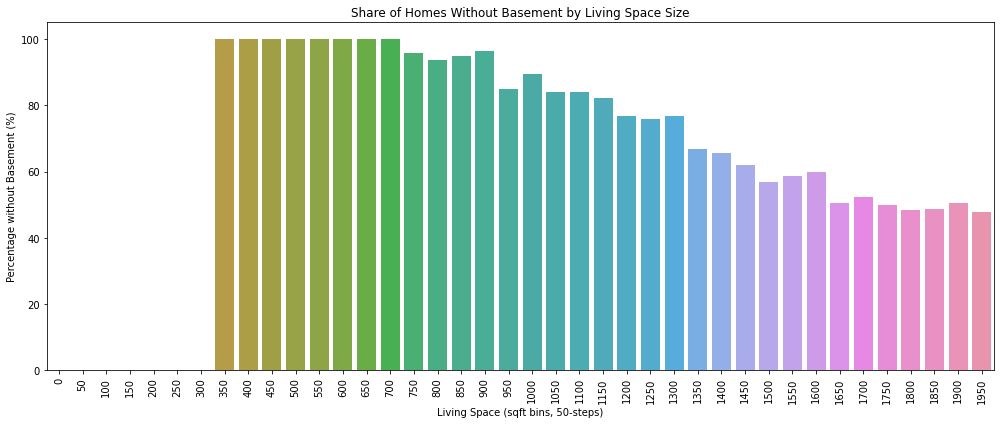

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

cutoff_sqft_living = 2000

# --- Filter data (cut at sqft_living) ---
df_filtered = df[df["sqft_living"] <= cutoff_sqft_living].copy()

# --- Create bins ---
bin_size = 50
bins = np.arange(0, cutoff_sqft_living + bin_size, bin_size)
labels = [f"{int(b)}" for b in bins[:-1]]

df_filtered["sqft_bin"] = pd.cut(
    df_filtered["sqft_living"],
    bins=bins,
    labels=labels,
    right=False
)

# --- Create basement indicator (1 = no basement, 0 = has basement) ---
df_filtered["no_basement"] = df_filtered["sqft_basement"] == 0

# --- Calculate percentage without basement per bin ---
# The average value of no_basement for each sqft_bin.
# True=1, False=0
percentage_df = (
    df_filtered
    .groupby("sqft_bin", observed=True)["no_basement"]
    .mean()
    .reset_index()
)

percentage_df["percent_no_basement"] = percentage_df["no_basement"] * 100

print(percentage_df.head())

# --- Plot ---
plt.figure(figsize=(14,6))

sns.barplot(
    data=percentage_df,
    x="sqft_bin",
    y="percent_no_basement"
)

plt.xticks(rotation=90)
plt.ylabel("Percentage without Basement (%)")
plt.xlabel(f"Living Space (sqft bins, {bin_size}-steps)")
plt.title("Share of Homes Without Basement by Living Space Size")
plt.tight_layout()
plt.show()


4. Hypothesis: Homes with no view are significantly more affordable.

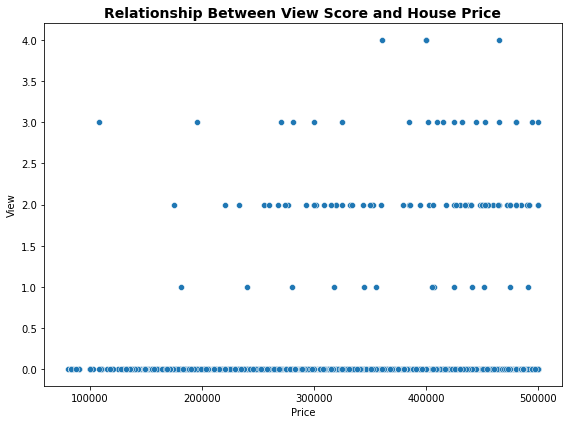

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

df_filtered = df[df["price"] <= 500000].copy()

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_filtered,
    x="price",
    y="view"
)

plt.title(
    "Relationship Between View Score and House Price",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Price")
plt.ylabel("View")

plt.tight_layout()

plt.savefig(
    "figure.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02,
    facecolor="white",
    transparent=False
)

plt.show()


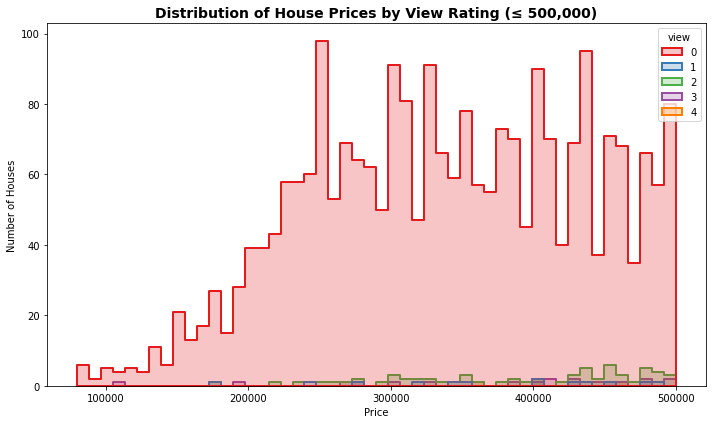

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter dataset
max_price = 500000
df_plot = df[df["price"] <= max_price]

plt.figure(figsize=(10,6))

sns.histplot(
    data=df_plot,
    x="price",
    hue="view",
    bins=50,
    element="step",
    stat="count",
    common_norm=False,
    linewidth=2,                     
    palette=sns.color_palette("Set1", 5)
)

plt.title(
    f"Distribution of House Prices by View Rating (≤ {max_price:,})",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Price")
plt.ylabel("Number of Houses")

plt.tight_layout()
plt.show()


BQ: When is the best time to buy or sell?


/home/F.abi/Desktop/Studium/Scientific Programming/ScientificProgrammingLab/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  import sys
/home/F.abi/Desktop/Studium/Scientific Programming/ScientificProgrammingLab/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  
/home/F.abi/Desktop/Studium/Scientific Programming/ScientificProgrammingLab/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  if __name__ == '__main__':


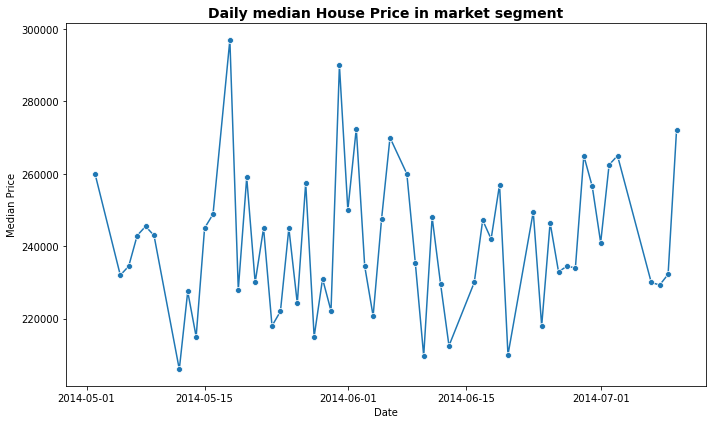

In [64]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df.copy()
df_plot = df_plot[df_plot["price"] <= 300000]
df_plot = df_plot[(df["floors"] <= 2) & (df["sqft_basement"] <= 1)]
df_plot = df_plot[df["condition"] >= 3]
df_plot = df_plot[df["sqft_living"] <= 2000] #185sq_m

# Convert to datetime
df_plot["date"] = pd.to_datetime(df_plot["date"])

# Create median
df_median = (
    df_plot
    .set_index("date")
    .resample("D")["price"] #Daily
    .median()
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=df_median,
    x="date",
    y="price",
	marker="o"
)

plt.title("Daily median House Price in market segment", fontsize=14, weight="bold")
plt.xlabel("Date")
plt.ylabel("Median Price")

plt.tight_layout()
plt.show()